**Exp 9: Implement a classification model to distinguish between normal and abnormal
physiological signals using extracted signal features. (perform comparative analysis on different ML models)**

Dataset Link: https://www.kaggle.com/datasets/shayanfazeli/heartbeat


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
import pickle

In [18]:
df=pd.read_csv('/content/drive/MyDrive/mitbih_test.csv',header=None)
df.columns=[f'x{i}' for i in range(187)]+['y']
print(df.head())

         x0        x1        x2        x3        x4        x5        x6  \
0  1.000000  0.758264  0.111570  0.000000  0.080579  0.078512  0.066116   
1  0.908425  0.783883  0.531136  0.362637  0.366300  0.344322  0.333333   
2  0.730088  0.212389  0.000000  0.119469  0.101770  0.101770  0.110619   
3  1.000000  0.910417  0.681250  0.472917  0.229167  0.068750  0.000000   
4  0.570470  0.399329  0.238255  0.147651  0.000000  0.003356  0.040268   

         x7        x8        x9  ...  x178  x179  x180  x181  x182  x183  \
0  0.049587  0.047521  0.035124  ...   0.0   0.0   0.0   0.0   0.0   0.0   
1  0.307692  0.296703  0.300366  ...   0.0   0.0   0.0   0.0   0.0   0.0   
2  0.123894  0.115044  0.132743  ...   0.0   0.0   0.0   0.0   0.0   0.0   
3  0.004167  0.014583  0.054167  ...   0.0   0.0   0.0   0.0   0.0   0.0   
4  0.080537  0.070470  0.090604  ...   0.0   0.0   0.0   0.0   0.0   0.0   

   x184  x185  x186    y  
0   0.0   0.0   0.0  0.0  
1   0.0   0.0   0.0  0.0  
2   0.0   0

In [19]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, x0 to y
dtypes: float64(188)
memory usage: 31.4 MB


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x178,x179,x180,x181,x182,x183,x184,x185,x186,y
count,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,...,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000,21892.000000
mean,0.894410,0.761902,0.426627,0.221596,0.201676,0.209891,0.204805,0.200992,0.197634,0.196022,...,0.004588,0.004327,0.004020,0.003789,0.003638,0.003459,0.003166,0.003000,0.002946,0.473689
std,0.234560,0.218659,0.228572,0.208711,0.177727,0.172194,0.177946,0.176142,0.170228,0.166707,...,0.043128,0.042187,0.040255,0.039397,0.038535,0.037717,0.035903,0.035522,0.035266,1.143447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.924260,0.683366,0.251197,0.050505,0.082873,0.087912,0.072663,0.065997,0.064516,0.068493,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.990431,0.828996,0.432777,0.167630,0.147642,0.158111,0.144068,0.144509,0.150422,0.149029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.912319,0.583991,0.347092,0.259211,0.287356,0.298453,0.294563,0.289907,0.282956,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.991429,...,0.980392,1.000000,0.966102,1.000000,1.000000,1.000000,1.000000,0.996053,1.000000,4.000000


In [20]:
df['y']=df['y'].astype(int)
print(df['y'].value_counts())

y
0    18118
4     1608
2     1448
1      556
3      162
Name: count, dtype: int64


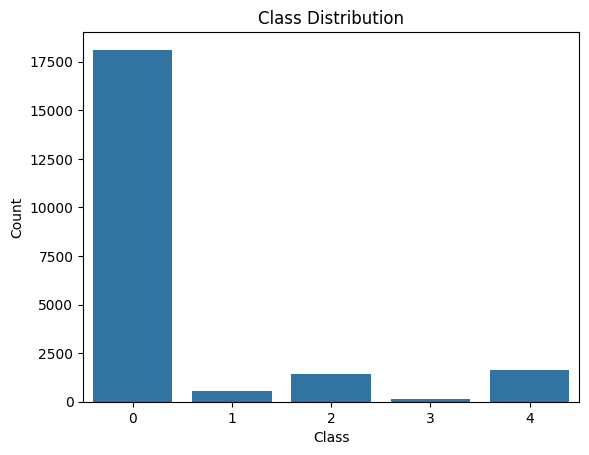

In [21]:
sns.countplot(x='y',data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [22]:
feature_cols=[f'x{i}' for i in range(187)]

In [23]:
print(df[feature_cols].isnull().sum().sum())

0


In [24]:
X=df[feature_cols]
y=df['y']

In [25]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=0,stratify=y)
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (17513, 187)
Test size: (4379, 187)


In [27]:
models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Random Forest":RandomForestClassifier(),
"SVM":SVC(),
"KNN":KNeighborsClassifier(),
"XGBoost":XGBClassifier(eval_metric='mlogloss')
}

In [28]:
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred,average='weighted')
    rec=recall_score(y_test,pred,average='weighted')
    f1w=f1_score(y_test,pred,average='weighted')
    f1m=f1_score(y_test,pred,average='macro')
    f1mi=f1_score(y_test,pred,average='micro')
    results.append([name,acc,pre,rec,f1w,f1m,f1mi])

In [29]:
results_df=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1_weighted","F1_macro","F1_micro"])
results_df

,Model,Accuracy,Precision,Recall,F1_weighted,F1_macro,F1_micro
0,Logistic Regression,0.917561,0.908050,0.917561,0.907757,0.686894,0.917561
1,Random Forest,0.967116,0.967232,0.967116,0.964763,0.836542,0.967116
2,SVM,0.955926,0.955235,0.955926,0.952063,0.769989,0.955926
3,KNN,0.958210,0.956327,0.958210,0.956085,0.806425,0.958210
4,XGBoost,0.973282,0.973215,0.973282,0.971709,0.880158,0.973282


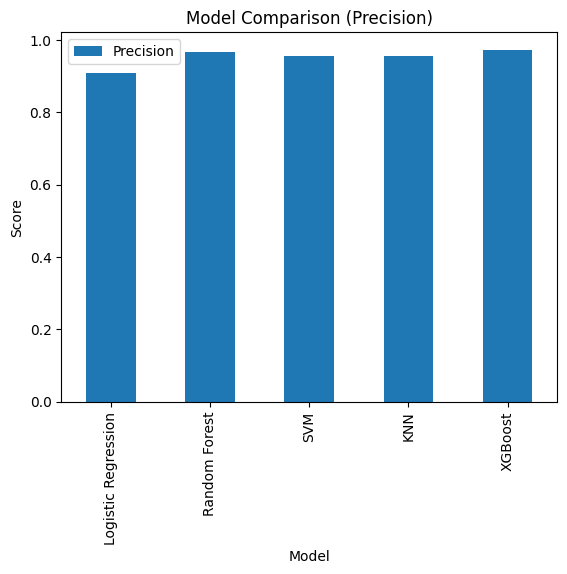

In [30]:
results_df.plot(x="Model",y="Precision",kind="bar")
plt.title("Model Comparison (Precision)")
plt.ylabel("Score")
plt.show()

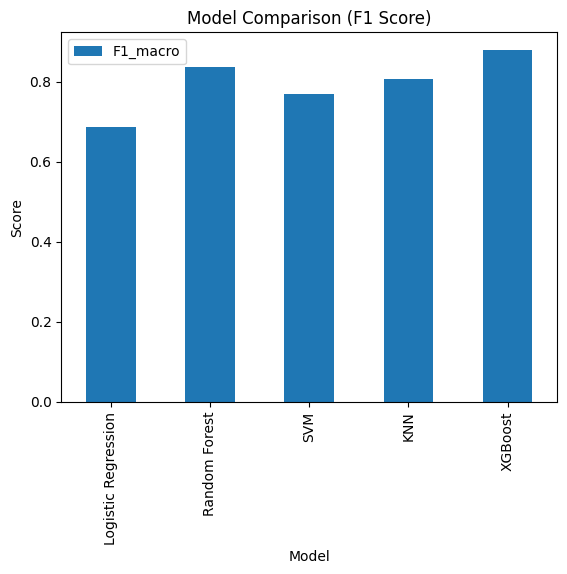

In [32]:
results_df.plot(x="Model",y="F1_macro",kind="bar")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("Score")
plt.show()

In [33]:
best_name=results_df.sort_values("F1_macro",ascending=False).iloc[0,0]
best_model=models[best_name]
print("Best Model:",best_name)

Best Model: XGBoost


In [34]:
with open("heartbeat_classifier.pkl","wb") as f:
    pickle.dump(best_model,f)

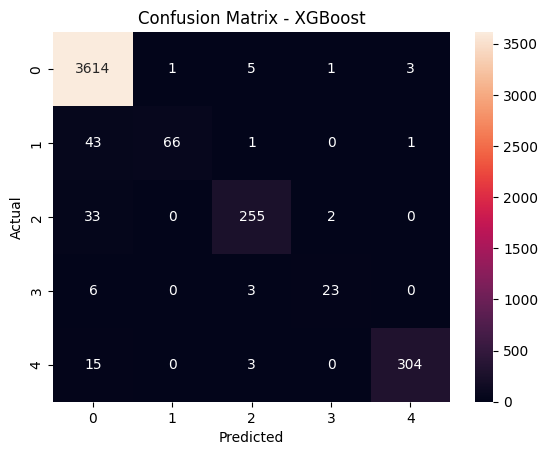

In [35]:
pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix - "+best_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3624
           1       0.99      0.59      0.74       111
           2       0.96      0.88      0.92       290
           3       0.88      0.72      0.79        32
           4       0.99      0.94      0.97       322

    accuracy                           0.97      4379
   macro avg       0.96      0.83      0.88      4379
weighted avg       0.97      0.97      0.97      4379

